# 02 — Exploratory Data Analysis

## Australian Energy Market Analytics

This notebook explores temporal patterns in electricity demand and spot prices
using Australian Energy Market Operator (AEMO) data.

### Objectives

- Examine the distribution of electricity demand and spot prices
- Identify daily and intraday demand patterns
- Compare weekday and weekend electricity consumption
- Investigate spot-price volatility
- Identify extreme and negative price events
- Develop hypotheses for subsequent demand-price analysis

## 1. Setup

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv(
    "../data/processed/clean_price_demand.csv",
    parse_dates=["SETTLEMENTDATE"]
)

df.head()

,REGION,SETTLEMENTDATE,TOTALDEMAND,RRP,PERIODTYPE
0,NSW1,2026-08-01 00:05:00,8898.91,89.88,TRADE
1,NSW1,2026-08-01 00:10:00,9032.33,95.05,TRADE
2,NSW1,2026-08-01 00:15:00,8989.12,88.88,TRADE
3,NSW1,2026-08-01 00:20:00,9036.72,88.88,TRADE
4,NSW1,2026-08-01 00:25:00,8946.67,84.79,TRADE


## 2. Descriptive Statistics

This section provides an initial overview of electricity demand and spot-price
behaviour before examining their temporal patterns.

In [5]:
df[["TOTALDEMAND", "RRP"]].describe()

,TOTALDEMAND,RRP
count,7776.000000,7776.000000
mean,8210.862065,77.059875
std,1295.783303,36.904946
min,4628.030000,-18.510000
25%,7297.312500,57.390000
50%,8129.005000,73.535000
75%,9112.190000,97.630000
max,11651.750000,311.910000


### Interpretation

The dataset contains 7,776 five-minute observations of electricity demand and
spot prices.

Electricity demand averaged approximately **8,210.86 MW**, with a median of
**8,129.01 MW**. The relatively small difference between the mean and median
suggests that demand is reasonably centred around 8,000 MW over the observed
period. Demand ranged from **4,628.03 MW** to **11,651.75 MW**, indicating
substantial variation in electricity consumption across different times of
the day and days of the month.

The average Regional Reference Price (RRP) was approximately **77.06/MWh**,
while the median was slightly lower at **73.54/MWh**. Prices ranged from
**-18.51/MWh**  to  **311.91/MWh**, demonstrating considerably greater
volatility than electricity demand. The negative minimum price is particularly
notable, as it indicates that electricity prices fell below zero during at
least one five-minute interval.

The relatively high maximum RRP compared with the upper quartile
(**$97.63/MWh**) also suggests the presence of occasional high-price events.
These observations motivate further investigation into the temporal patterns
of demand, negative prices, and price spikes.

### Relative Variability

To compare the variability of electricity demand and spot prices on a common
scale, the coefficient of variation (CV) is calculated as:

$$
CV = \frac{\sigma}{\mu} \times 100\%
$$

Electricity demand has a coefficient of variation of approximately **15.8%**,
while the Regional Reference Price (RRP) has a substantially higher coefficient
of variation of approximately **47.9%**.

This indicates that **spot prices are considerably more volatile relative to
their average level than electricity demand**. While electricity demand shows
moderate variation around its mean, spot prices experience much larger relative
fluctuations, suggesting the presence of periods of elevated price volatility.

This motivates further investigation into the timing and magnitude of electricity
price fluctuations in the subsequent analysis.

In [6]:
demand_cv = df["TOTALDEMAND"].std() / df["TOTALDEMAND"].mean() * 100
price_cv = df["RRP"].std() / df["RRP"].mean() * 100

print(f"Demand coefficient of variation: {demand_cv:.2f}%")
print(f"Price coefficient of variation: {price_cv:.2f}%")

Demand coefficient of variation: 15.78%
Price coefficient of variation: 47.89%


## 3. Electricity Demand Analysis

### 3.1 Demand Over Time

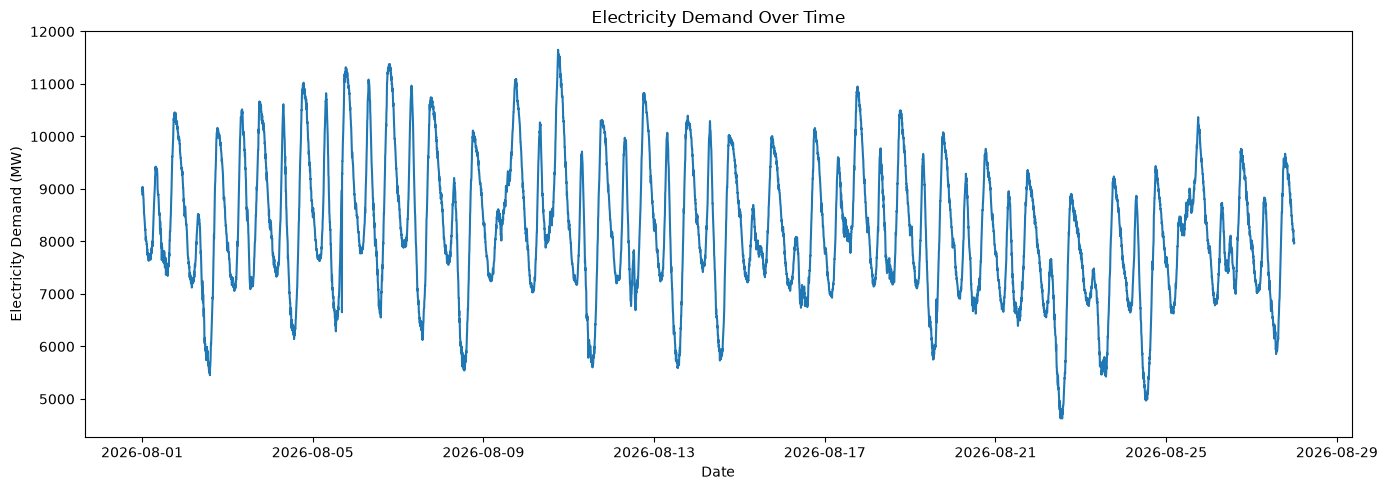

In [7]:
plt.figure(figsize=(14, 5))

plt.plot(
    df["SETTLEMENTDATE"],
    df["TOTALDEMAND"]
)

plt.xlabel("Date")
plt.ylabel("Electricity Demand (MW)")
plt.title("Electricity Demand Over Time")

plt.tight_layout()
plt.show()

### Interpretation

Electricity demand shows a clear **repeating daily pattern**, with demand rising
and falling substantially throughout each day. This suggests that time of day
is an important factor influencing electricity consumption.

The magnitude of the daily peaks also varies across the month. Demand reaches
some of its highest levels during the first half of August, while several
lower-demand periods are visible later in the month.

Overall, the strong cyclical pattern suggests that electricity demand has a
significant **intraday structure**. The next analysis examines average demand
by hour to identify when demand typically reaches its highest and lowest levels.

### 3.2 Average demand by hour 

To examine the intraday pattern identified in the demand time series, average
electricity demand is calculated for each hour of the day. This aggregation
helps identify typical peak and off-peak demand periods across the observed month.

In [9]:
df["hour"] = df["SETTLEMENTDATE"].dt.hour

hourly_demand = (
    df.groupby("hour")["TOTALDEMAND"]
      .mean()
)

hourly_demand

hour
0      8156.722006
1      7753.040864
2      7399.262870
3      7227.329877
4      7255.101265
5      7675.494753
6      8595.545494
7      9264.047099
8      8816.454444
9      7973.653580
10     7305.452068
11     6993.775556
12     6812.080679
13     6697.161049
14     6823.865556
15     7470.055556
16     8559.396142
17     9685.544877
18    10214.853920
19    10047.503704
20     9778.584074
21     9333.665062
22     8849.014074
23     8373.085000
Name: TOTALDEMAND, dtype: float64

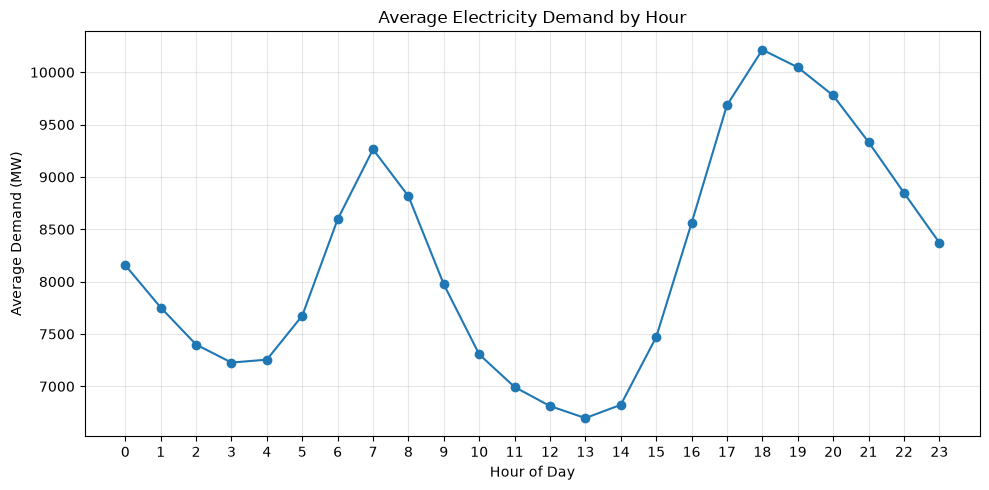

Peak demand hour: 18:00 (10,214.85 MW)
Lowest demand hour: 13:00 (6,697.16 MW)


In [11]:
plt.figure(figsize=(10, 5))

plt.plot(
    hourly_demand.index,
    hourly_demand.values,
    marker="o"
)

plt.xlabel("Hour of Day")
plt.ylabel("Average Demand (MW)")
plt.title("Average Electricity Demand by Hour")

plt.xticks(range(0, 24))
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

peak_hour = hourly_demand.idxmax()
peak_demand = hourly_demand.max()

lowest_hour = hourly_demand.idxmin()
lowest_demand = hourly_demand.min()

print(f"Peak demand hour: {peak_hour}:00 ({peak_demand:,.2f} MW)")
print(f"Lowest demand hour: {lowest_hour}:00 ({lowest_demand:,.2f} MW)")

### Interpretation

Electricity demand follows a clear **intraday pattern**, with two noticeable
peaks during the day. Demand increases rapidly in the early morning, reaching
a local peak around **07:00**, before declining through the late morning and
early afternoon.

The lowest average demand occurs at **13:00**, at approximately **6,697 MW**.
After this point, demand rises sharply throughout the afternoon and reaches
its daily maximum at **18:00**, with an average demand of approximately
**10,215 MW**.

The evening peak is substantially higher than the morning peak, indicating
that the **17:00–20:00 period is the highest-demand period** in the dataset.
Overall, the results demonstrate that electricity demand varies considerably
by time of day, with a pronounced evening peak and an early-afternoon trough.

### 3.3 Daily Demand 

Now we investigate the daily electricity demand. More specifically, we want to know whether the electricity demand differs between weekdays and weekends.

In [12]:
df["date"] = df["SETTLEMENTDATE"].dt.date

daily_demand = (
    df.groupby("date")["TOTALDEMAND"]
      .mean()
)

daily_demand

date
2026-08-01    8666.048467
2026-08-02    7840.596285
2026-08-03    8683.738264
2026-08-04    8517.526910
2026-08-05    8765.828403
2026-08-06    9055.279687
2026-08-07    8719.730139
2026-08-08    8057.637813
2026-08-09    8833.707569
2026-08-10    8926.576285
2026-08-11    7999.811597
2026-08-12    8491.827778
2026-08-13    8138.279722
2026-08-14    8216.653611
2026-08-15    8325.436007
2026-08-16    7970.231840
2026-08-17    8663.432535
2026-08-18    8446.784028
2026-08-19    7958.518299
2026-08-20    7984.281875
2026-08-21    7750.353333
2026-08-22    6994.901632
2026-08-23    7224.926319
2026-08-24    7304.010313
2026-08-25    8369.894931
2026-08-26    8003.038542
2026-08-27    7786.626840
2026-08-28    7973.910000
Name: TOTALDEMAND, dtype: float64

In [13]:
df["day_of_week"] = df["SETTLEMENTDATE"].dt.day_name()

day_demand = (
    df.groupby("day_of_week")["TOTALDEMAND"]
      .mean()
)

day_demand

day_of_week
Friday       8228.617561
Monday       8394.439349
Saturday     8010.436872
Sunday       7967.365503
Thursday     8241.117031
Tuesday      8333.504366
Wednesday    8304.803255
Name: TOTALDEMAND, dtype: float64

In [17]:
df["day_number"] = df["SETTLEMENTDATE"].dt.dayofweek

day_number_demand = (
    df.groupby("day_number")["TOTALDEMAND"]
       .mean()
)

day_number_demand

day_number
0    8394.439349
1    8333.504366
2    8304.803255
3    8241.117031
4    8228.617561
5    8010.436872
6    7967.365503
Name: TOTALDEMAND, dtype: float64

In [22]:
# We can see the weekends are the rows with index >= 5
df["is_weekend"] = df["day_number"] >= 5

weekend_demand = (
    df.groupby("is_weekend")["TOTALDEMAND"]
      .mean()
      .rename(index={False: "Weekday", True: "Weekend"})
)

weekend_demand

is_weekend
Weekday    8304.265580
Weekend    7988.891837
Name: TOTALDEMAND, dtype: float64

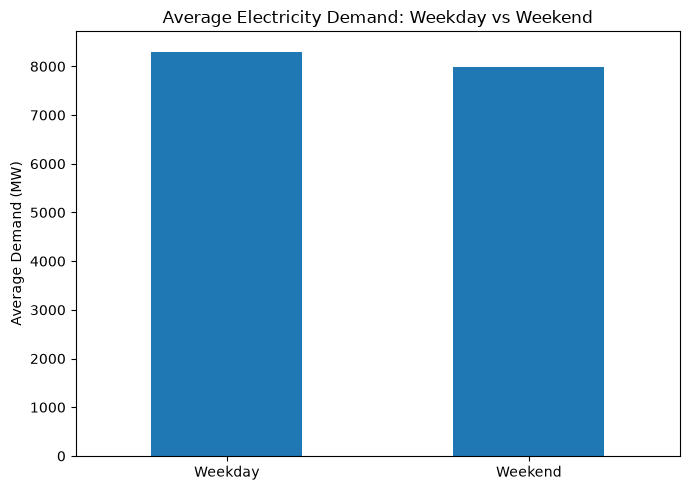

In [23]:
plt.figure(figsize=(7, 5))

weekend_demand.plot(kind="bar")

plt.ylabel("Average Demand (MW)")
plt.xlabel("")
plt.title("Average Electricity Demand: Weekday vs Weekend")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [25]:
hourly_weekday = (
    df.groupby(["hour", "is_weekend"])["TOTALDEMAND"]
      .mean()
      .unstack()
)

hourly_weekday.columns = ["Weekday", "Weekend"]

hourly_weekday

,Weekday,Weekend
hour,,
0,8092.518952,8311.485158
1,7703.329211,7871.106042
2,7361.886053,7488.032813
3,7208.180088,7272.810625
4,7271.509912,7216.130729
5,7790.490789,7402.379167
6,8898.535175,7875.945000
7,9660.749693,8321.878437
8,9100.960702,8140.752083


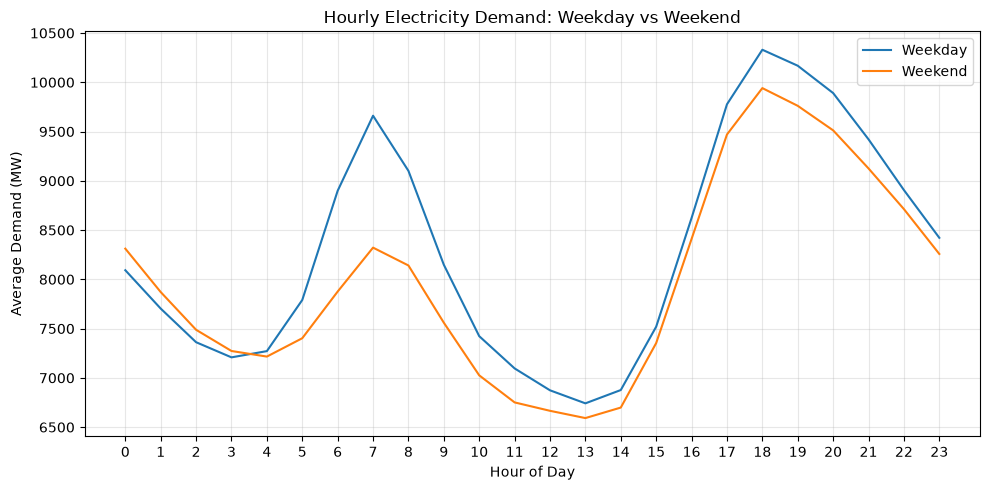

In [26]:
plt.figure(figsize=(10, 5))

plt.plot(
    hourly_weekday.index,
    hourly_weekday["Weekday"],
    label="Weekday"
)

plt.plot(
    hourly_weekday.index,
    hourly_weekday["Weekend"],
    label="Weekend"
)

plt.xlabel("Hour of Day")
plt.ylabel("Average Demand (MW)")
plt.title("Hourly Electricity Demand: Weekday vs Weekend")
plt.xticks(range(24))
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 4. Electricity Spot Price Analysis

### 4.1 Spot Price Over Time

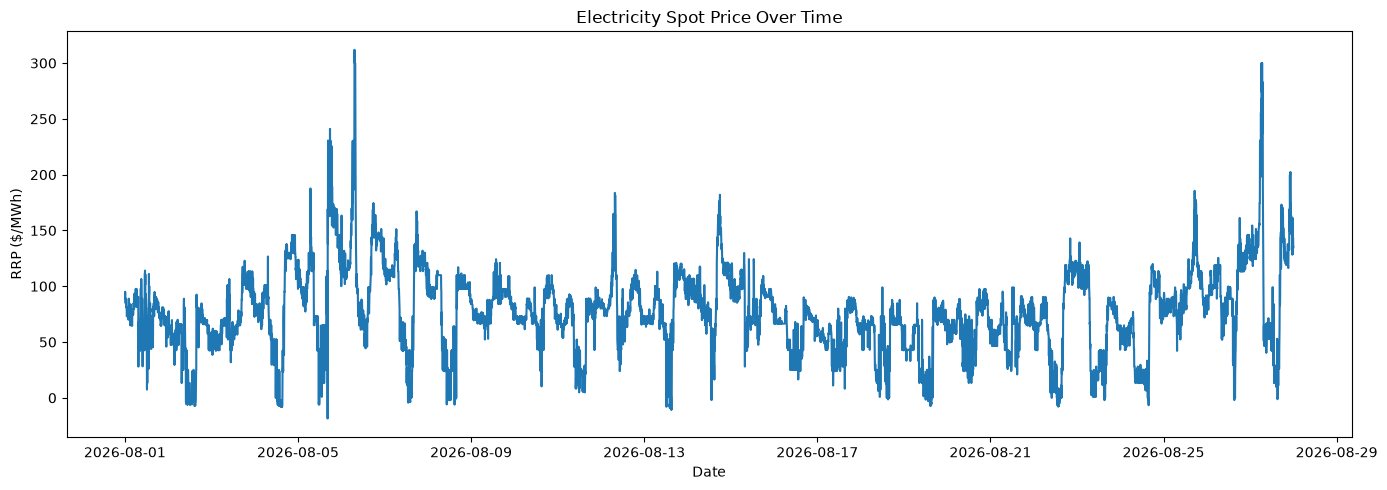

In [28]:
plt.figure(figsize=(14, 5))

plt.plot(
    df["SETTLEMENTDATE"],
    df["RRP"]
)

plt.xlabel("Date")
plt.ylabel("RRP ($/MWh)")
plt.title("Electricity Spot Price Over Time")

plt.tight_layout()
plt.show()

In [29]:
df["RRP"].describe()

count    7776.000000
mean       77.059875
std        36.904946
min       -18.510000
25%        57.390000
50%        73.535000
75%        97.630000
max       311.910000
Name: RRP, dtype: float64

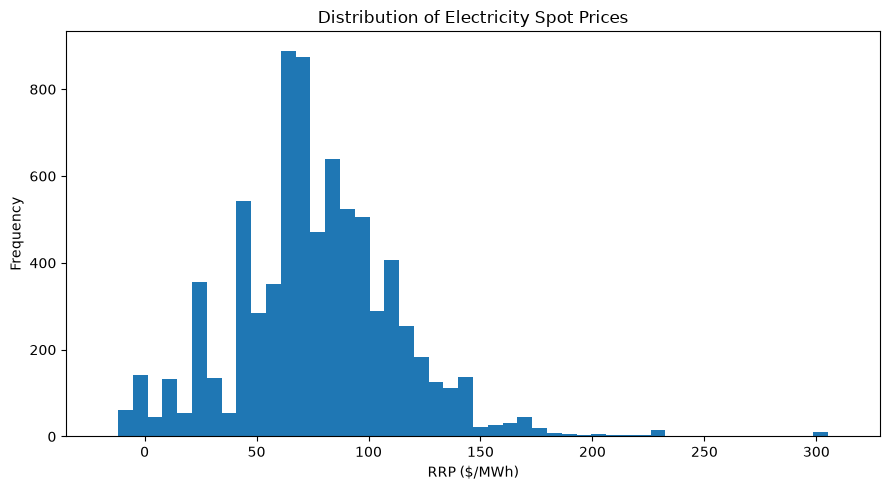

In [30]:
plt.figure(figsize=(9, 5))

plt.hist(
    df["RRP"],
    bins=50
)

plt.xlabel("RRP ($/MWh)")
plt.ylabel("Frequency")
plt.title("Distribution of Electricity Spot Prices")

plt.tight_layout()
plt.show()

### 4.2 Extreme Price Events

In [31]:
top_prices = (
    df.nlargest(10, "RRP")
      [["SETTLEMENTDATE", "TOTALDEMAND", "RRP"]]
)

top_prices

,SETTLEMENTDATE,TOTALDEMAND,RRP
1527,2026-08-06 07:20:00,11073.64,311.91
1528,2026-08-06 07:25:00,11084.10,299.99
1529,2026-08-06 07:30:00,11042.73,299.99
1530,2026-08-06 07:35:00,10997.83,299.99
1531,2026-08-06 07:40:00,11033.31,299.99
1532,2026-08-06 07:45:00,11004.31,299.99
7565,2026-08-27 06:30:00,8353.35,299.99
7563,2026-08-27 06:20:00,8240.49,299.98
7566,2026-08-27 06:35:00,8490.12,299.98
7567,2026-08-27 06:40:00,8582.96,299.98


In [32]:
top_prices["hour"] = top_prices["SETTLEMENTDATE"].dt.hour
top_prices

,SETTLEMENTDATE,TOTALDEMAND,RRP,hour
1527,2026-08-06 07:20:00,11073.64,311.91,7
1528,2026-08-06 07:25:00,11084.10,299.99,7
1529,2026-08-06 07:30:00,11042.73,299.99,7
1530,2026-08-06 07:35:00,10997.83,299.99,7
1531,2026-08-06 07:40:00,11033.31,299.99,7
1532,2026-08-06 07:45:00,11004.31,299.99,7
7565,2026-08-27 06:30:00,8353.35,299.99,6
7563,2026-08-27 06:20:00,8240.49,299.98,6
7566,2026-08-27 06:35:00,8490.12,299.98,6
7567,2026-08-27 06:40:00,8582.96,299.98,6


In [33]:
negative_prices = df[df["RRP"] < 0]

print(f"Number of negative-price intervals: {len(negative_prices):,}")
print(
    f"Percentage of observations: "
    f"{len(negative_prices) / len(df) * 100:.2f}%"
)

Number of negative-price intervals: 140
Percentage of observations: 1.80%


In [34]:
negative_prices[
    ["SETTLEMENTDATE", "TOTALDEMAND", "RRP"]
].head(10)

,SETTLEMENTDATE,TOTALDEMAND,RRP
405,2026-08-02 09:50:00,7034.87,-2.77
406,2026-08-02 09:55:00,7249.85,-5.28
410,2026-08-02 10:15:00,6838.49,-5.50
411,2026-08-02 10:20:00,6994.35,-5.40
415,2026-08-02 10:40:00,6566.35,-6.29
416,2026-08-02 10:45:00,6721.04,-5.58
417,2026-08-02 10:50:00,6645.26,-5.44
418,2026-08-02 10:55:00,6527.16,-5.72
433,2026-08-02 12:10:00,5901.86,-6.46
434,2026-08-02 12:15:00,5990.23,-5.27
